<div style="background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);padding:44px 32px;border-radius:20px;text-align:center;font-family:Georgia,serif;">
  <div style="font-size:0.85em;letter-spacing:4px;color:#a78bfa;text-transform:uppercase;margin-bottom:8px;">Kaggle · Playground Series · Season 6 · Episode 4</div>
  <h1 style="color:#f8f8ff;font-size:2.5em;margin:0 0 10px;letter-spacing:1px;">🌱 Predicting Irrigation Need</h1>
  <h2 style="color:#c4b5fd;font-size:1.2em;font-weight:400;margin:0 0 20px;">Ensemble of Solutions · Version 10</h2>
  <p style="color:#ddd6fe;font-size:1em;max-width:680px;margin:0 auto 24px;line-height:1.9;">
    Combine the best public submissions via <b style='color:#f0abfc'>smart voting schemas</b> that exploit model disagreements on the rare
    <code style='background:#4c1d95;padding:2px 7px;border-radius:4px;color:#e9d5ff'>High</code> class —
    pushing the leaderboard beyond <b style='color:#34d399'>0.98145 ✦</b>
  </p>
  <div style="display:flex;justify-content:center;gap:14px;flex-wrap:wrap;">
    <span style="background:#1e1b4b;color:#a5f3fc;padding:6px 18px;border-radius:50px;font-size:0.85em;">🏅 Best LB · 0.98_148</span>
    <span style="background:#1e1b4b;color:#fbcfe8;padding:6px 18px;border-radius:50px;font-size:0.85em;">🗳️ 3 Voting Schemas</span>
    <span style="background:#1e1b4b;color:#bbf7d0;padding:6px 18px;border-radius:50px;font-size:0.85em;">🤝 6 Public Solutions</span>
  </div>
</div>

<div style="background:#1e1b4b;border-left:5px solid #818cf8;padding:18px 24px;border-radius:10px;margin:16px 0 8px;">
<b style="color:#a5b4fc;font-size:1.05em;">🧠 Why this works</b><br><br>
<span style="color:#c7d2fe;line-height:1.9;">
Vladimir Demidov's <b>RealMLP</b> (LB 0.98_092) says <b>298</b> cases are <code>High</code> — not Medium.<br>
Our top solution (LB <b>0.98_145</b>) disagrees on ~400 of those <code>High</code> cases with the NN.<br>
Mikhail Naumov's ensemble is famously sharp on Playground Series competitions.<br><br>
➡ We use <b>F.A.Nina's 0.98145</b> as the oracle tie-breaker and write schemas that correct<br>
outlier <code>High</code> predictions — winning if we move beyond <b style='color:#34d399'>[0.98_092 … 0.98_145]</b>.
</span>
</div>

---

## 🏆 Source Solutions

| # | LB Score | Notebook | Author | Country |
|---|----------|----------|--------|---------|
| 1 | [0.97_904](https://www.kaggle.com/code/yekenot/ps-s6-e4-realmlp-slightly-polished) | PS.S6.E4: RealMLP [slightly polished] | Vladimir Demidov | 🇷🇺 |
| 2 | [0.97_971](https://www.kaggle.com/code/yunsuxiaozi/pss6e4-lgb-baselinecv-0-97943) | PSS6E4 lgb baseline CV:0.97943 | yunsuxiaozi | 🇨🇳 |
| 3 | [0.98_039](https://www.kaggle.com/code/mikhailnaumov/irrigation-need-ensemble) | Irrigation Need · Ensemble | Mikhail Naumov | 🌍 |
| 4 | [0.98_109](https://www.kaggle.com/code/rawashishsin/s6e4-highest-score-xgboost-cv-0-98109) | S6E4 · Highest Score XGBoost | AshishSinghRawat | 🇮🇳 |
| 5 ⭐ | [**0.98_145**](https://www.kaggle.com/code/nina2025/ps-s6e4-ensemble-of-solutions-9) | PS-s6e4 · Ensemble of solutions (9) | F.A.Nina | 🇬🇪 |
| 6 | [0.98_119](https://www.kaggle.com/code/beraterolelk/oof-meta-stacking-with-golden-features) | OOF Meta-Stacking with Golden Features | Berat Erol ÇELİK | 🇹🇷 |
| 7 | [0.98_113](https://www.kaggle.com/code/kashifalikhan360/ensemble-0-979979-simplest-xgb) | Ensemble · 0.979979 · Simplest · XGB | kashifalikhan360 | 🇮🇳 |
| 8 | [0.98_134](https://www.kaggle.com/code/nina2025/ps-s6e4-ensemble-of-solutions-8) | PS-s6e4 · Ensemble of solutions (8) | F.A.Nina | 🇬🇪 |

## 📋 Version History (this notebook)

| Version | LB Score | Models used | Schema |
|---------|----------|-------------|--------|
| v1 | 0.98_126 | 1, 2, 3, 4 vs 5 | schema1 |
| v2 | 0.98_129 | 1, 2, 3, 4 vs 5 | schema4 |
| v3 | 0.98_145 | 1, 3, 6, 7, 8 vs 5 | schema3 |
| v4 | 0.98_132 | 1, 3, 6, 7, 8 vs 5 | schema5 |
| **v5** | **🥇 0.98_148** | 1, 3, 6, 7, 8 vs 5 | **schema8** |

---
## ⚙️ Setup & Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────────
pkw = '/kaggle/working/'
pps = '/kaggle/input/competitions/playground-series-s6e4/'
pds = '/kaggle/input/datasets/nina2025/ps-s6e4-20/'

sub = pd.read_csv(pps + 'sample_submission.csv')
print(f'✅ Sample submission: {len(sub):,} rows')
sub.head()

✅ Sample submission: 270,000 rows


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


---
## 🛠️ Helper Functions

| Function | What it does |
|---|---|
| `merge` | Inner-join a list of DataFrames on `id` |
| `microEDA` | Encode each row as a pattern string: `'L _ H _ _ '` (L=Low, \_=Medium, H=High) |
| `vote` | Apply a schema function row-by-row; **writes `wh` into `dfs` in-place** so heatmaps work |
| `comparison` | For conflict rows, mark disagreements as NaN — feeds the heatmap null-mask |
| `display_heatmaps` | 2×3 grid of disagreement heatmaps (viridis + Blues) |

In [2]:
# ── Core helpers ───────────────────────────────────────────────────────────────

def merge(list_df):
    """Inner-join all DataFrames in list_df on the 'id' column."""
    dfs = pd.merge(list_df[0], list_df[1], on='id')
    for i in range(2, len(list_df)):
        dfs = pd.merge(dfs, list_df[i], on='id')
    return dfs


def microEDA(x, list_names_df):
    """
    Collapse one row of predictions into a compact pattern string.
    'L' = Low  |  '_' = Medium  |  'H' = High
    Example output: 'L _ H _ _ '
    """
    lwh = []
    for _p in list_names_df:
        wh = x[_p][0:1]
        if wh == 'M': wh = '_'
        lwh.append(f'{wh} ')
    return ''.join(lwh)


def vote(lns, f_vote_schema, dfs, details=True):
    """
    Apply a voting schema and return a ready-to-submit DataFrame.

    Writes 'wh' (pattern column) directly into `dfs` in-place so that
    display_heatmaps() can read it without a separate call.

    Parameters
    ----------
    lns          : list[str]  — prediction column names (last = oracle)
    f_vote_schema: callable   — row-level voting function
    dfs          : DataFrame  — merged predictions (mutated in-place)
    details      : bool       — print pattern counts + tail preview
    """
    dfs['wh'] = dfs.apply(lambda x: microEDA(x, lns), axis=1)
    if details:
        display(dfs.tail(2))
        print("'L' - Low,  '_' - Medium,  'H' - High")
        print('\n', dfs['wh'].value_counts())
    df = pd.read_csv(pps + 'sample_submission.csv')
    df['Irrigation_Need'] = dfs.apply(lambda x: f_vote_schema(x, lns), axis=1)
    return df


def comparison(lns, dfs, value_target):
    """
    On conflict rows: replace values equal to value_target with None (NaN),
    leaving mismatches as the class name — drives the heatmap null-mask.
    """
    dfc = dfs.drop(['id', 'wh'], axis=1).copy()
    def comp(x, value_target, lns):
        return [value_target if x[ln] != value_target else None for ln in lns]
    dfc[lns] = dfc.apply(lambda x: comp(x, value_target, lns), axis=1, result_type='expand')
    return dfc


def heatmap_show(value_target, cell_axes, color_map, dfs):
    ax = cell_axes
    ax.set_title(value_target, fontsize=10)
    sns.heatmap(dfs.isnull(), cbar=False, cmap=color_map, ax=ax)


def display_heatmaps(lns, dfs, qp=5):
    """
    2×3 grid of disagreement heatmaps (viridis + Blues) for Low / Medium / High.
    Only shows rows where at least one model disagrees (conflict rows).

    Requires 'wh' column in dfs — created automatically by vote().
    qp = number of models (4–7).
    """
    unanimous = {
        4: ['L L L L ', '_ _ _ _ ', 'H H H H '],
        5: ['L L L L L ', '_ _ _ _ _ ', 'H H H H H '],
        6: ['L L L L L L ', '_ _ _ _ _ _ ', 'H H H H H H '],
        7: ['L L L L L L L ', '_ _ _ _ _ _ _ ', 'H H H H H H H '],
    }[qp]

    dfs_loc = dfs.loc[~dfs['wh'].isin(unanimous)]

    dfs_low    = comparison(lns, dfs_loc, 'Low')
    dfs_medium = comparison(lns, dfs_loc, 'Medium')
    dfs_high   = comparison(lns, dfs_loc, 'High')

    fig, axes = plt.subplots(2, 3, figsize=(11, 4))
    heatmap_show('Low',    axes[1, 0], 'Blues',   dfs_low)
    heatmap_show('Medium', axes[1, 1], 'Blues',   dfs_medium)
    heatmap_show('High',   axes[1, 2], 'Blues',   dfs_high)
    heatmap_show('Low',    axes[0, 0], 'viridis', dfs_low)
    heatmap_show('Medium', axes[0, 1], 'viridis', dfs_medium)
    heatmap_show('High',   axes[0, 2], 'viridis', dfs_high)
    plt.show()

---
## 🗳️ Voting Schemas

The **last column** in `N` (`df5` · LB 0.98_145) acts as the oracle tie-breaker.

| Schema | Rule |
|--------|------|
| `f_vote_schema1` | First 4 models agree → keep; else → oracle (`df5`) |
| `f_vote_schema3` | First 5 models agree → keep; else → oracle (`df5`) |
| `f_vote_schema4` | Pattern `H H H H _ ` → force **High**; else → `df5` |
| `f_vote_schema5` | Lone H (`H _ _ _ _ _ `) → **Medium**; else → `df1` |
| **`f_vote_schema8`** ⭐ | **Lone or paired H → Medium; else → `df1`** · Best: 0.98_148 |

In [3]:
def f_vote_schema1(x, lns):
    """If the first 4 models agree, return their vote; else fall back to oracle."""
    _lns, _1vs = lns[:-1], lns[-1]
    if x[_lns[0]] == x[_lns[1]] == x[_lns[2]] == x[_lns[3]]:
        return x[_lns[0]]
    return x[_1vs]


def f_vote_schema3(x, lns):
    """If the first 5 models agree, return their vote; else fall back to oracle."""
    _lns, _1vs = lns[:-1], lns[-1]
    if x[_lns[0]] == x[_lns[1]] == x[_lns[2]] == x[_lns[3]] == x[_lns[4]]:
        return x[_lns[0]]
    return x[_1vs]


def f_vote_schema4(x, lns):
    """4 models say High but oracle says Medium → trust the 4 and return High."""
    if x['wh'] == 'H H H H _ ':
        return 'High'
    return x['df5']


def f_vote_schema5(x, lns):
    """Lone High outlier in a sea of Medium → probably wrong, flip to Medium."""
    if x['wh'] == 'H _ _ _ _ _ ':
        return 'Medium'
    return x['df1']


def f_vote_schema8(x, lns):
    """
    Best schema (LB 0.98_148).
    Lone or paired High outlier → reclassify as Medium.
    All other cases → follow df1 (RealMLP, LB 0.98_092).
    """
    if x['wh'] == 'H _ _ _ _ _ ':
        return 'Medium'
    if x['wh'] == 'H H _ _ _ _ ':
        return 'Medium'
    return x['df1']

---
## 📥 Load Submissions & Run Ensemble

> 🔧 Change `f_vote_schema8` to any other schema to explore different strategies.

,id,df1,df3,df6,df7,df8,df5,wh
269998,899998,Low,Low,Low,Low,Low,Low,L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L     159219
_ _ _ _ _ _      99524
H H H H H H       9910
H _ _ _ _ _        298
_ H _ _ _ _        243
H _ H H H H        146
H H _ _ _ _        115
L _ L L _ _         74
L L _ _ L L         71
_ _ L L _ _         67
_ L L L L L         57
L _ _ _ _ _         55
_ _ H H _ _         42
L _ L L _ L         42
_ _ H H H H         20
H _ H H _ _         20
_ L _ _ L L         19
_ L _ _ L _         18
_ H H H H H         14
L L L _ L L          6
L _ _ L _ _          6
L L _ _ L _          6
_ _ L L _ L          5
L L _ L L L          5
_ _ L _ _ L          4
L L _ L L _          4
_ _ _ L _ _          3
_ L _ L L _          3
L _ L _ _ L          2
L _ L _ _ _          1
_ _ L _ _ _          1
Name: count, dtype: int64


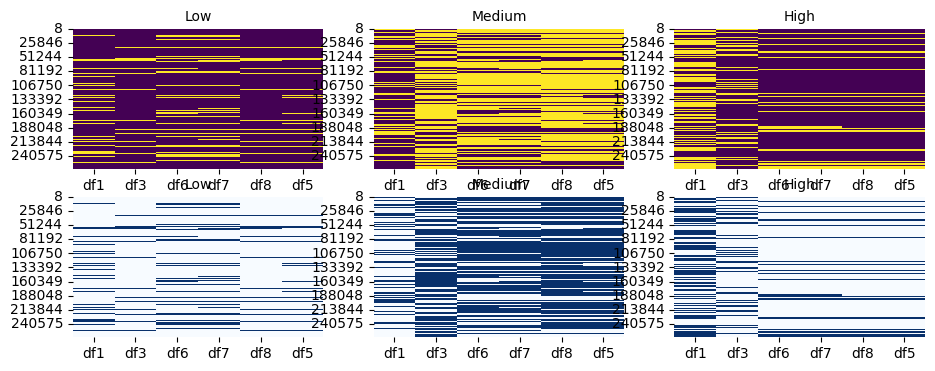

In [4]:
# ── Load each public submission ────────────────────────────────────────────────
df1 = pd.read_csv(pds + '0.98092.csv').rename(columns={'Irrigation_Need': 'df1'})
df3 = pd.read_csv(pds + '0.98039.csv').rename(columns={'Irrigation_Need': 'df3'})
df6 = pd.read_csv(pds + '0.98119.csv').rename(columns={'Irrigation_Need': 'df6'})
df7 = pd.read_csv(pds + '0.98113.csv').rename(columns={'Irrigation_Need': 'df7'})
df8 = pd.read_csv(pds + '0.98134.csv').rename(columns={'Irrigation_Need': 'df8'})

# Oracle / tie-breaker  (highest individual LB)
df5 = pd.read_csv(pds + '0.98145.csv').rename(columns={'Irrigation_Need': 'df5'})

# ── Merge & vote ───────────────────────────────────────────────────────────────
D, N = [df1, df3, df6, df7, df8, df5], ['df1', 'df3', 'df6', 'df7', 'df8', 'df5']

dfs  = merge(D)

# vote() writes 'wh' into dfs in-place → display_heatmaps() reads it directly
dfv5 = vote(N, f_vote_schema8, dfs, details=True)

display_heatmaps(N, dfs, qp=6)

In [5]:
dfs = pd.merge(dfs, dfv5, on='id')
dfs.head()

,id,df1,df3,df6,df7,df8,df5,wh,Irrigation_Need
0,630000,Low,Low,Low,Low,Low,Low,L L L L L L,Low
1,630001,Low,Low,Low,Low,Low,Low,L L L L L L,Low
2,630002,Low,Low,Low,Low,Low,Low,L L L L L L,Low
3,630003,Low,Low,Low,Low,Low,Low,L L L L L L,Low
4,630004,Low,Low,Low,Low,Low,Low,L L L L L L,Low


---
## 🔍 Comparison vs `df1` Baseline

In [6]:
def compare(x):
    return '=' if x['df1'] == x['Irrigation_Need'] else '!='

dfs['compare'] = dfs.apply(compare, axis=1)

display(dfs.head(), dfs['compare'].value_counts())

,id,df1,df3,df6,df7,df8,df5,wh,Irrigation_Need,compare
0,630000,Low,Low,Low,Low,Low,Low,L L L L L L,Low,=
1,630001,Low,Low,Low,Low,Low,Low,L L L L L L,Low,=
2,630002,Low,Low,Low,Low,Low,Low,L L L L L L,Low,=
3,630003,Low,Low,Low,Low,Low,Low,L L L L L L,Low,=
4,630004,Low,Low,Low,Low,Low,Low,L L L L L L,Low,=


compare
=     269587
!=       413
Name: count, dtype: int64

---
## 💾 Submit

In [7]:
sub['Irrigation_Need'] = dfs['Irrigation_Need']

In [8]:
sub.to_csv('submission.csv', index=False)
sub

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


<div style="background:linear-gradient(135deg,#064e3b,#065f46);padding:28px 32px;border-radius:14px;text-align:center;margin-top:24px;">
  <h3 style="color:#6ee7b7;margin:0 0 10px;">🙏 If this helped you, an upvote means the world!</h3>
  <p style="color:#a7f3d0;margin:0;font-size:0.95em;line-height:1.8;">
    All credit to the original authors:<br>
    <b>Vladimir Demidov · Mikhail Naumov · yunsuxiaozi · AshishSinghRawat · Berat Erol ÇELİK · kashifalikhan360 · F.A.Nina</b>
  </p>
</div>